In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("ai_resume_screening.csv")

In [7]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [9]:
df.shape

(30000, 7)

In [11]:
df.columns.tolist()

['years_experience',
 'skills_match_score',
 'education_level',
 'project_count',
 'resume_length',
 'github_activity',
 'shortlisted']

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


In [15]:
df.isnull().sum()


years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64

In [17]:
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


In [19]:
df["shortlisted"].value_counts()

shortlisted
Yes    20966
No      9034
Name: count, dtype: int64

In [21]:
df["education_level"].value_counts()

education_level
Bachelors      13461
Masters        10524
PhD             3024
High School     2991
Name: count, dtype: int64

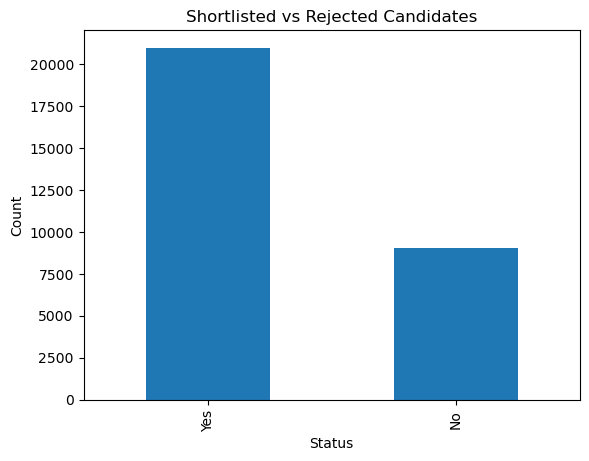

In [23]:
df["shortlisted"].value_counts().plot(kind="bar")

plt.title("Shortlisted vs Rejected Candidates")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

In [25]:
df.to_csv(
    "hiresmart_cleaned.csv",
    index=False
)

In [27]:
from sklearn.preprocessing import LabelEncoder

le_edu = LabelEncoder()
df["education_level"] = le_edu.fit_transform(df["education_level"])

le_target = LabelEncoder()
df["shortlisted"] = le_target.fit_transform(df["shortlisted"])

df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,0,7,234,158,0
1,3,59.1,2,5,502,77,0
2,12,100.0,2,12,753,381,1
3,14,66.8,1,8,529,407,1
4,10,99.6,0,10,754,331,1


In [29]:
X = df.drop("shortlisted", axis=1)

y = df["shortlisted"]

print(X.shape)
print(y.shape)

(30000, 6)
(30000,)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [35]:
pred = rf.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.8991666666666667


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[1470  337]
 [ 268 3925]]


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1807
           1       0.92      0.94      0.93      4193

    accuracy                           0.90      6000
   macro avg       0.88      0.87      0.88      6000
weighted avg       0.90      0.90      0.90      6000



In [43]:
probability = rf.predict_proba(X)

df["Candidate Score"] = (
    probability[:,1] * 100
).round(2)

In [45]:
df["Candidate Rank"] = (
    df["Candidate Score"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [47]:
df["Fit Level"] = pd.cut(
    df["Candidate Score"],
    bins=[0,60,80,100],
    labels=[
        "Low Fit",
        "Medium Fit",
        "High Fit"
    ]
)

In [49]:
df[
[
"Candidate Score",
"Candidate Rank",
"Fit Level"
]
].head()

,Candidate Score,Candidate Rank,Fit Level
0,15.5,170.0,Low Fit
1,4.0,193.0,Low Fit
2,100.0,1.0,High Fit
3,97.5,6.0,High Fit
4,100.0,1.0,High Fit


In [51]:
df["Fit Level"].value_counts()

Fit Level
High Fit      19424
Low Fit        7658
Medium Fit     1397
Name: count, dtype: int64

In [53]:
df.to_csv(
    "hiresmart_final.csv",
    index=False
)

In [55]:
df["Prediction"] = rf.predict(X)

In [57]:
df["Prediction"] = df["Prediction"].map({
    1:"Shortlisted",
    0:"Rejected"
})

In [59]:
df["shortlisted"] = df["shortlisted"].map({
    1:"Shortlisted",
    0:"Rejected"
})

In [61]:
print(le_edu.classes_)

['Bachelors' 'High School' 'Masters' 'PhD']


In [65]:
df["education_level"].head()

0    0
1    2
2    2
3    1
4    0
Name: education_level, dtype: int32

In [67]:
df.to_csv(
    "hiresmart_final.csv",
    index=False
)

In [69]:
df.columns.tolist()

['years_experience',
 'skills_match_score',
 'education_level',
 'project_count',
 'resume_length',
 'github_activity',
 'shortlisted',
 'Candidate Score',
 'Candidate Rank',
 'Fit Level',
 'Prediction']